In [1]:
import os
import time
import platform
from shutil import rmtree
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as image
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':  # Mac OS
    plt.rc('font', family='AppleGothic')
else:  # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 오류 발생시
# sklearn.set_config(display="text")

# Intel Image Classification 분류 데이터셋
- Intel Image Classification 데이터셋은 인텔(Intel)이 호스팅한 해커톤/컴퓨터 비전 경진대회용 데이터셋으로,  
  자연 풍경 및 도시 공간 이미지로 구성된 6개 클래스 분류 데이터셋입니다.

[Intel Image Classification 링크](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

### Intel Image Classification 클래스 정보 (6개)
| 클래스 번호 | 클래스명 (영문) | 설명 (한글) |
| :---: | :---: | :---: |
| 0 | buildings | 건물 |
| 1 | forest | 숲 |
| 2 | glacier | 빙하 |
| 3 | mountain | 산 |
| 4 | sea | 바다 |
| 5 | street | 거리 |


### 이미지 데이터 크기
- Intel Image Classification 데이터셋의 원본 이미지는 150 × 150 픽셀 크기로 구성되어 있습니다. 단일 이미지 한 장을 기준으로 볼 때 전체 픽셀 수는 총 22,500개에 해당합니다. 만약 이 데이터가 흑백(Grayscale) 이미지라면 단일 채널이므로 입력 필드의 값이 22,500개가 되지만, 해당 데이터셋은 RGB 컬러 이미지이므로 Red, Green, Blue에 해당하는 3개의 색상 레이어가 각각 존재하게 됩니다. 이에 따라 이미지 한 장당 실제 모델에 입력되는 값은 22,500에 3을 곱한 총 67,500개의 필드 데이터로 확장됩니다.

In [2]:
load_dotenv()

print(os.environ["KAGGLE_API_TOKEN"][:10])

KGAT_f8814


In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

output_dir = r"C:\kdt_0900_pjh\machine_learning\resource\datasets"
# 없으면 생성
os.makedirs(output_dir, exist_ok=True)

# https://www.kaggle.com/datasets/puneet6060/intel-image-classification
api.dataset_download_files(r"puneet6060/intel-image-classification", path=output_dir, unzip=True)

print("Intel Image 다운로드 완료")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
Intel Image 다운로드 완료


In [7]:
categories = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

class_names = dict(enumerate(categories))
class_names

{0: 'buildings',
 1: 'forest',
 2: 'glacier',
 3: 'mountain',
 4: 'sea',
 5: 'street'}

In [8]:
base_path = output_dir
train_path = os.path.join(base_path, "seg_train", "seg_train")
test_path = os.path.join(base_path, "seg_test", "seg_test")

In [47]:
train_transform = transforms.Compose([
    transforms.Resize((150, 150)), # 이미지 크기가 모두 다를 수 있기 떄문에 
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((150, 150)), # 이미지 크기가 모두 다를 수 있기 떄문에 
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

## ※ transforms.Normalize(mean, std)
- 텐서로 변환된 이미지의 픽셀 값을 정규화(normalization)합니다.
- mean: 각 채널(R, G, B)의 평균값. std: 각 채널의 표준편차.
- mean=[0.5, 0.5, 0.5]: R, G, B 채널 각각의 평균을 0.5로 설정.
- std=[0.5, 0.5, 0.5]: R, G, B 채널 각각의 표준편차를 0.5로 설정.
- 이 정규화는 일반적으로 픽셀 값의 범위를 [-1,1] [-1, 1][-1,1]로 조정하기 위해 사용됩니다.
- (픽셀 값이 [O,1][O,1][0,1]로 변환된 상태에서 == toTensor를 한 상태에서)
    - 예) x = [0.2, 0.4, 0.7, 0.9] 경우 모두 양수이므로 그대로 통과
    - 예) x = [-0.8,-0.2, 0.3, 0.91] 경우 ReLU를 통과하면 [0.0, 0.0, 0.3, 0.9]
      - 0.0으로 죽는 값이 생기지만 그런 값들을 살짝의 음수로 바꾸어 살리기 위한 목적으로 사용한다.
     
## ※ datasets.ImageFolder()
- 이미지 데이터를 특정 디렉터리 구조에서 로드하는 클래스입니다.  
디렉터리 이름을 레이블(class label)로 간주하며, 각 디렉터리 내의 이미지 파일들을 해당 레이블에 할당합니다.  
이 클래스는 이미지 데이터를 PyTorch 데이터셋(Dataset) 형식으로 변환하므로, DataLoader와 함께 사용하여  
배치 처리 및 데이터 증강 (data augmentation)을 쉽게 적용할 수 있습니다.

In [48]:
full_train_dataset = ImageFolder(train_path, transform=train_transform)

total_size = len(full_train_dataset)
val_size = int(total_size * 0.2)
train_size = total_size - val_size
print(total_size, train_size, val_size)

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(2026))
test_dataset = ImageFolder(test_path, transform=test_transform)
print(test_dataset)

14034 11228 2806
Dataset ImageFolder
    Number of datapoints: 3000
    Root location: C:\kdt_0900_pjh\machine_learning\resource\datasets\seg_test\seg_test
    StandardTransform
Transform: Compose(
               Resize(size=(150, 150), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )


In [49]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [50]:
imgs, labels = next(iter(train_dataloader))

In [51]:
class_names[labels[0].item()]

'glacier'

In [52]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])

    # 정규화를 원래대로 되돌림
    img = img * std + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.show()

['glacier', 'street', 'forest', 'street']


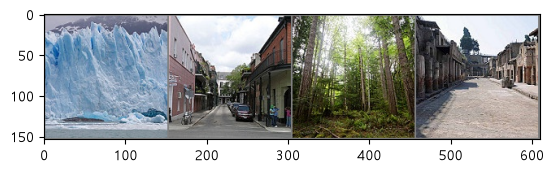

In [53]:
print([class_names[labels[i].item()] for i in range(4)])
out = make_grid(imgs[:4])
imshow(out)

In [54]:
class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()
        self.linear = nn.Linear(150 * 150 * 3, 6)
        self.flatten = nn.Flatten()
        
    # Module의 상속받은 메서드
    # 이 부분이 2개 이상의 모델을 사용할 때 딥러닝이라고 한다.
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [55]:
class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.linear1 = nn.Linear(150 * 150 * 3, 64)
        self.linear2 = nn.Linear(64, 6)
        self.flatten = nn.Flatten()
        
    # Module의 상속받은 메서드
    # 이 부분이 2개 이상의 모델을 사용할 때 딥러닝이라고 한다.
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.linear2(x)
        return x

In [56]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"현재 선택된 장치: {device}")

현재 선택된 장치: xpu


In [57]:
model1 = Model1().to(device)

In [58]:
optimizer = optim.Adam(model1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# model = model.to(device)

In [59]:
log_step = 10
epochs = 15

# 가장 좋았던 지점을 저장하기 위해 변수
best_val_acc = 0
best_epoch = 0

# epoch마다 history
history = []
accuracy = []

In [60]:
model1_path = os.path.join(base_path, r"weights/Model1")
model2_path = os.path.join(base_path, r"weights/Model2")
model3_path = os.path.join(base_path, r"weights/Model3")

In [61]:
os.makedirs(model1_path, exist_ok=True)
os.makedirs(model2_path, exist_ok=True)
os.makedirs(model3_path, exist_ok=True)

In [74]:
def train_one_epoch(model, dataloader, criterion, optimizer, device=device):
    model.train()
    total = 0.0
    sum_loss = torch.tensor(0.0, device=device)
    sum_acc = torch.tensor(0.0, device=device)

    for i, (imgs, labels) in enumerate(dataloader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad() # 기울기 초기화
        outputs = model(imgs) # 순전파
        loss = criterion(outputs, labels) # 손실 계산
        loss.backward() # 역전파
        optimizer.step() # 기울기 업데이트

        # 정확도 계산
        sum_loss += loss.detach()
        y_pred_index = outputs.argmax(dim=1)
        acc = (y_pred_index == labels).float().mean() * 100   # outputs → y_pred_index, y_pred_index → labels
        sum_acc += acc

    avg_loss = (sum_loss / len(dataloader)).item()   # train_loader → dataloader
    avg_acc = (sum_acc / len(dataloader)).item()

    return avg_loss, avg_acc

In [75]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device=device):
    model.eval()

    sum_losses = torch.tensor(0.0, device=device)
    sum_accs = torch.tensor(0.0, device=device)

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        sum_losses += loss.detach()
        
        y_pred_index = y_pred.argmax(dim=1)
        acc = (y_batch.squeeze() == y_pred_index).float().mean() * 100
        sum_accs += acc

    avg_loss = (sum_losses / len(dataloader)).item()
    avg_acc = (sum_accs / len(dataloader)).item()

    return avg_loss, avg_acc

In [77]:
def train_model(model, model_name, train_loader, val_loader, criterion, optimizer, epochs, device, save_base_dir):
    save_dir = os.path.join(save_base_dir, model_name)
    os.makedirs(save_dir, exist_ok=True)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0

    # 학습 시작
    print(f"--------------------{model_name} 학습 시작--------------------")
    for epoch in range(epochs):
        lr = optimizer.param_groups[0]["lr"]

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Train Accurracy: {train_acc:.2f}")
        print(f"Epoch: {epoch+1} | Validation Loss: {val_loss:.4f} | Validation Accurracy: {val_acc:.2f}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model.pth"))

        torch.save(model.state_dict(), os.path.join(save_dir, f"last_model_{epochs}.pth"))

    return history

In [65]:
model1 = Model1().to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

history1 = train_model(
    model=model1,
    model_name="Model1", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader, 
    criterion=criterion, 
    optimizer=optimizer1, 
    epochs=10, 
    device=device,
    save_base_dir=os.path.join(base_path, "weights")
)

--------------------Model1 학습 시작--------------------
Epoch: 1 | Train Loss: 3.9313 | Train Accurracy: 41.43
Epoch: 1 | Validation Loss: 4.5327 | Validation Accurracy: 37.63
Epoch: 2 | Train Loss: 3.3016 | Train Accurracy: 46.17
Epoch: 2 | Validation Loss: 3.7893 | Validation Accurracy: 41.04
Epoch: 3 | Train Loss: 3.1866 | Train Accurracy: 49.02
Epoch: 3 | Validation Loss: 3.7908 | Validation Accurracy: 39.87
Epoch: 4 | Train Loss: 2.5192 | Train Accurracy: 53.87
Epoch: 4 | Validation Loss: 3.2854 | Validation Accurracy: 45.09
Epoch: 5 | Train Loss: 2.8768 | Train Accurracy: 54.07
Epoch: 5 | Validation Loss: 4.1612 | Validation Accurracy: 43.84
Epoch: 6 | Train Loss: 2.5100 | Train Accurracy: 56.40
Epoch: 6 | Validation Loss: 4.0543 | Validation Accurracy: 39.16
Epoch: 7 | Train Loss: 2.3649 | Train Accurracy: 58.92
Epoch: 7 | Validation Loss: 4.1808 | Validation Accurracy: 45.73
Epoch: 8 | Train Loss: 2.3662 | Train Accurracy: 60.01
Epoch: 8 | Validation Loss: 4.1555 | Validation Accu

{'train_loss': [3.93131685256958,
  3.3016278743743896,
  3.1866352558135986,
  2.5192043781280518,
  2.8767781257629395,
  2.5099968910217285,
  2.364877939224243,
  2.36618971824646,
  2.180689811706543,
  2.431527853012085],
 'val_loss': [4.532720565795898,
  3.7893409729003906,
  3.7907650470733643,
  3.285447597503662,
  4.16116189956665,
  4.054315090179443,
  4.180849075317383,
  4.155466556549072,
  4.230266571044922,
  4.291329383850098],
 'train_acc': [41.431617736816406,
  46.16730880737305,
  49.01709747314453,
  53.86693572998047,
  54.0660514831543,
  56.399654388427734,
  58.92223358154297,
  60.00659942626953,
  62.16264343261719,
  61.24949645996094],
 'val_acc': [37.63152313232422,
  41.04324722290039,
  39.87137222290039,
  45.086280822753906,
  43.83680725097656,
  39.158512115478516,
  45.73206329345703,
  43.56850051879883,
  45.244110107421875,
  45.18886947631836]}

## 모델 평가

In [78]:
base_path

'C:\\kdt_0900_pjh\\machine_learning\\resource\\datasets'

## 모델의 가중치 로드

In [79]:
base_model_path = os.path.join(base_path, "weights", "Model1", "best_model.pth")
base_model_path

model1.load_state_dict(torch.load(base_model_path, weights_only=False))

<All keys matched successfully>

In [80]:
test_loss, test_acc = evaluate(model1, test_dataloader, criterion, device)

In [82]:
print(f"Test | Test Loss: {test_loss:.4f}, Test Accurracy: {test_acc:.2f}%")

Test | Test Loss: 4.3470, Test Accurracy: 44.35%


In [83]:
class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.linear1 = nn.Linear(150 * 150 * 3, 64)
        self.linear2 = nn.Linear(64, 6)
        self.flatten = nn.Flatten()
        
    # Module의 상속받은 메서드
    # 이 부분이 2개 이상의 모델을 사용할 때 딥러닝이라고 한다.
    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.linear2(x)
        return x

In [84]:
model2 = Model2().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

history2 = train_model(
    model=model2,
    model_name="Model2", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader, 
    criterion=criterion, 
    optimizer=optimizer2, 
    epochs=10, 
    device=device,
    save_base_dir=os.path.join(base_path, "weights")
)

--------------------Model2 학습 시작--------------------
Epoch: 1 | Train Loss: 4.4417 | Train Accurracy: 40.81
Epoch: 1 | Validation Loss: 1.6362 | Validation Accurracy: 46.25
Epoch: 2 | Train Loss: 1.2529 | Train Accurracy: 54.22
Epoch: 2 | Validation Loss: 1.3058 | Validation Accurracy: 49.89
Epoch: 3 | Train Loss: 1.1660 | Train Accurracy: 56.93
Epoch: 3 | Validation Loss: 1.3042 | Validation Accurracy: 52.67
Epoch: 4 | Train Loss: 1.1458 | Train Accurracy: 57.84
Epoch: 4 | Validation Loss: 1.2918 | Validation Accurracy: 52.38
Epoch: 5 | Train Loss: 1.1148 | Train Accurracy: 59.07
Epoch: 5 | Validation Loss: 1.2935 | Validation Accurracy: 52.36
Epoch: 6 | Train Loss: 1.0973 | Train Accurracy: 59.89
Epoch: 6 | Validation Loss: 1.3255 | Validation Accurracy: 52.54
Epoch: 7 | Train Loss: 1.0751 | Train Accurracy: 60.93
Epoch: 7 | Validation Loss: 1.3248 | Validation Accurracy: 52.56
Epoch: 8 | Train Loss: 1.0578 | Train Accurracy: 61.65
Epoch: 8 | Validation Loss: 1.3719 | Validation Accu

{'train_loss': [4.441728591918945,
  1.2528671026229858,
  1.165999174118042,
  1.145821452140808,
  1.1148148775100708,
  1.0973379611968994,
  1.0751292705535889,
  1.0577929019927979,
  1.0217580795288086,
  1.0287691354751587],
 'val_loss': [1.6361510753631592,
  1.3058058023452759,
  1.304173231124878,
  1.2918161153793335,
  1.2934815883636475,
  1.3254555463790894,
  1.3247871398925781,
  1.3718723058700562,
  1.4065258502960205,
  1.4122085571289062],
 'train_acc': [40.81397247314453,
  54.22078323364258,
  56.925987243652344,
  57.84294128417969,
  59.06681442260742,
  59.892452239990234,
  60.93115997314453,
  61.64519500732422,
  63.10242462158203,
  63.06691360473633],
 'val_acc': [46.25157928466797,
  49.88689041137695,
  52.67255783081055,
  52.37531661987305,
  52.35953140258789,
  52.543670654296875,
  52.56339645385742,
  49.796138763427734,
  49.754051208496094,
  49.780357360839844]}

In [87]:
base_model_path = os.path.join(base_path, "weights", "Model2", "best_model.pth")
base_model_path

model2.load_state_dict(torch.load(base_model_path, weights_only=False))

<All keys matched successfully>

In [88]:
test_loss, test_acc = evaluate(model2, test_dataloader, criterion, device)

In [89]:
print(f"Test | Test Loss: {test_loss:.4f}, Test Accurracy: {test_acc:.2f}%")

Test | Test Loss: 1.3210, Test Accurracy: 51.89%


In [96]:
def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    extract_vals = lambda lst: [x.detach().cpu().item() if isinstance(x, torch.Tensor) else float(x) for x in lst]
    
    axes[0].plot(epochs, extract_vals(history["train_loss"]), "blue", label="Train Loss")
    axes[0].plot(epochs, extract_vals(history["val_loss"]), "red", label="Validation Loss")
    axes[0].set_title(f"[{model_name}] Loss History")
    axes[0].set_xlabel("epochs")
    axes[0].set_ylabel("Loss (Total/Batch Sum)")
    axes[0].grid(True, linestyle=":", alpha=0.4)
    axes[0].legend()
    
    axes[1].plot(epochs, extract_vals(history["train_acc"]), "blue", label="Train Accuracy")
    axes[1].plot(epochs, extract_vals(history["val_acc"]), "red", label="Validation Accuracy")
    axes[1].set_title(f"[{model_name}] Accuracy History")
    axes[1].set_xlabel("epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, linestyle=":", alpha=0.4)
    axes[1].legend()

    plt.show()

In [97]:
plot_history(history, "Model2")

TypeError: list indices must be integers or slices, not str

In [98]:
class Model3(nn.Module):
    def __init__(self):
        super(Model3, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(150 * 150 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 6),
        )
        
    # Module의 상속받은 메서드
    # 이 부분이 2개 이상의 모델을 사용할 때 딥러닝이라고 한다.
    def forward(self, x):
        return self.net(x)

In [100]:
model3 = Model3().to(device)
optimizer3 = optim.Adam(model3.parameters(), lr=0.001)

history3 = train_model(
    model=model3,
    model_name="Model3", 
    train_loader=train_dataloader, 
    val_loader=val_dataloader, 
    criterion=criterion, 
    optimizer=optimizer3, 
    epochs=10, 
    device=device,
    save_base_dir=os.path.join(base_path, "weights")
)

--------------------Model3 학습 시작--------------------
Epoch: 1 | Train Loss: 1.9280 | Train Accurracy: 26.58
Epoch: 1 | Validation Loss: 1.5588 | Validation Accurracy: 44.60
Epoch: 2 | Train Loss: 1.5970 | Train Accurracy: 34.15
Epoch: 2 | Validation Loss: 1.3968 | Validation Accurracy: 48.12
Epoch: 3 | Train Loss: 1.5016 | Train Accurracy: 38.96
Epoch: 3 | Validation Loss: 1.3145 | Validation Accurracy: 49.77
Epoch: 4 | Train Loss: 1.4389 | Train Accurracy: 42.50
Epoch: 4 | Validation Loss: 1.3082 | Validation Accurracy: 50.31
Epoch: 5 | Train Loss: 1.4019 | Train Accurracy: 44.26
Epoch: 5 | Validation Loss: 1.2906 | Validation Accurracy: 52.13
Epoch: 6 | Train Loss: 1.3803 | Train Accurracy: 45.24
Epoch: 6 | Validation Loss: 1.2902 | Validation Accurracy: 51.32
Epoch: 7 | Train Loss: 1.3630 | Train Accurracy: 45.61
Epoch: 7 | Validation Loss: 1.2639 | Validation Accurracy: 51.88
Epoch: 8 | Train Loss: 1.3599 | Train Accurracy: 46.60
Epoch: 8 | Validation Loss: 1.2854 | Validation Accu

In [101]:
base_model_path = os.path.join(base_path, "weights", "Model3", "best_model.pth")
base_model_path

model3.load_state_dict(torch.load(base_model_path, weights_only=False))

<All keys matched successfully>

In [103]:
test_loss, test_acc = evaluate(model3, test_dataloader, criterion, device)

In [104]:
print(f"Test | Test Loss: {test_loss:.4f}, Test Accurracy: {test_acc:.2f}%")

Test | Test Loss: 1.2357, Test Accurracy: 51.39%
